#### Gift Idea Generator
This notebook demonstrates how to build a simple map-reduce-style workflow using LangGraph. Given a short description of a friend, the system:

- Extracts a few relevant interests or personality traits.
- Generates personalized gift ideas for each interest (map).
- Selects the most thoughtful gift among them (reduce).

In [1]:
import os, getpass
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

from dotenv import load_dotenv
load_dotenv()

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("AZURE_OPENAI_API_KEY")
_set_env("AZURE_OPENAI_ENDPOINT")

def fetch_LLM():
    return AzureChatOpenAI(
        model="gpt-4o",
        api_version="2024-10-21",
        temperature=0,
    )

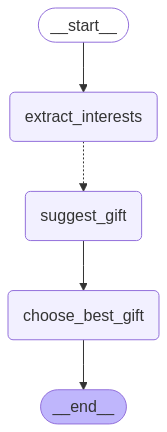

In [2]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.types import Send
from langgraph.graph import END, StateGraph, START
from pydantic import BaseModel, Field
from IPython.display import Image

# prompts
interests_prompt = """List between 2 and 5 specific interests, hobbies, or personality traits that could guide gift ideas for someone described as: 
'{description}'.
Return them as a comma-separated list."""

gift_prompt = """Suggest a unique gift idea for someone who enjoys or is described as: {interest}."""

best_gift_prompt = """Here are a few gift ideas for someone described as "{description}". Pick the most thoughtful or unique one and return the index (starting from 0).

{gifts}
"""


# output schemas
class Interests(BaseModel):
    interests: list[str]

class Gift(BaseModel):
    idea: str

class BestGift(BaseModel):
    id: int = Field(description="Index of the best gift, starting with 0")

class OverallState(TypedDict):
    description: str
    interests: list[str]
    gift_ideas: Annotated[list, operator.add]
    best_gift: str

class GiftState(TypedDict):
    interest: str

# graph nodes
def extract_interests(state: OverallState):
    prompt = interests_prompt.format(description=state["description"])
    response = model.with_structured_output(Interests).invoke(prompt)
    return {"interests": response.interests}

def suggest_gift(state: GiftState):
    prompt = gift_prompt.format(interest=state["interest"])
    response = model.with_structured_output(Gift).invoke(prompt)
    return {"gift_ideas": [response.idea]}

def plan_gift_routes(state: OverallState):
    return [Send("suggest_gift", {"interest": interest}) for interest in state["interests"]]

def choose_best_gift(state: OverallState):
    gifts = "\n\n".join(f"{idx}. {g}" for idx, g in enumerate(state["gift_ideas"]))
    prompt = best_gift_prompt.format(description=state["description"], gifts=gifts)
    response = model.with_structured_output(BestGift).invoke(prompt)
    return {"best_gift": state["gift_ideas"][response.id]}

model = fetch_LLM()

# build and compile the graph
graph = StateGraph(OverallState)
graph.add_node("extract_interests", extract_interests)
graph.add_node("suggest_gift", suggest_gift)
graph.add_node("choose_best_gift", choose_best_gift)

graph.add_edge(START, "extract_interests")
graph.add_conditional_edges("extract_interests", plan_gift_routes, ["suggest_gift"])
graph.add_edge("suggest_gift", "choose_best_gift")
graph.add_edge("choose_best_gift", END)

app = graph.compile()


Image(app.get_graph().draw_mermaid_png())


In [3]:
for step in app.stream({"description": "my outdoorsy and coffee-loving best friend who just moved to a new city"}):
    print(step)

{'extract_interests': {'interests': ['Hiking and exploring nature', 'Coffee brewing and tasting', 'Urban exploration and sightseeing', 'Home organization and decor', 'Local community engagement']}}
{'suggest_gift': {'gift_ideas': ['A personalized topographic map of their favorite hiking area, framed for display.']}}
{'suggest_gift': {'gift_ideas': ['A personalized map highlighting local community landmarks and events, paired with a donation to a community project in their name.']}}
{'suggest_gift': {'gift_ideas': ['A subscription to a specialty coffee bean service that delivers unique and rare coffee varieties from around the world monthly.']}}
{'suggest_gift': {'gift_ideas': ['A high-quality urban exploration backpack equipped with essential tools like a flashlight, multi-tool, and a guidebook to hidden city spots.']}}
{'suggest_gift': {'gift_ideas': ['A personalized wall-mounted key and mail organizer with their initials or a meaningful design engraved.']}}
{'choose_best_gift': {'bes